## DP1 ECDFS coadd PSF characterisation

This notebook creates the coadd-PSF validation figures used for the
DP1 ECDFS LSST--VISTA fusion paper.

The analysis uses one representative, fully covered patch

The notebook produces two figures:

1. a diagnostic figure with peak-normalized PSF stamps and box plots of
   the PSF FWHM across the patch;
2. the final paper figure with peak-normalized PSF stamps and two-dimensional
   maps of the spatial FWHM variation.

Run the notebook from top to bottom on the UK Rubin Science Platform.


### 1. Imports and configuration

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from astropy.visualization import AsinhStretch, ImageNormalize

import lsst.daf.butler as dafButler
import lsst.geom as geom


# ------------------------------------------------------------------
# UK RSP Butler repositories and collections
# ------------------------------------------------------------------

COMCAM_REPO = "dp1"
COMCAM_COLLECTION = "LSSTComCam/DP1"
COMCAM_DATASET_TYPE = "deep_coadd"

VIRCAM_REPO = "lsst-ir-fusion-dp1"
VIRCAM_DATASET_TYPE = "deepCoadd_calexp"

# Search all collections in the fusion repository.
VIRCAM_SEARCH_COLLECTIONS = ...

# Prefer the validated VIRCAM coadd-output run when duplicate
# DatasetRefs are visible through more than one collection.
VIRCAM_PREFERRED_RUN = (
    "u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z"
)

SKYMAP = "lsst_cells_v1"


# ------------------------------------------------------------------
# ECDFS reference coordinate
# ------------------------------------------------------------------

# This coordinate is used only to identify the ECDFS tract.
FIELD_RA_DEG = 53.28911
FIELD_DEC_DEG = -28.16056

# Patch 16 was selected after checking several candidate patches.
# It has valid PSF evaluations at all 36 grid positions in all bands.
SELECTED_PATCH = 16


# ------------------------------------------------------------------
# Bands and labels
# ------------------------------------------------------------------

COMCAM_BANDS = ["u", "g", "r", "i", "z", "y"]
VIRCAM_BANDS = ["Z", "Y", "J", "H", "K"]
ALL_BANDS = COMCAM_BANDS + VIRCAM_BANDS

PANEL_LABELS = {
    "u": r"$u$",
    "g": r"$g$",
    "r": r"$r$",
    "i": r"$i$",
    "z": r"$z$",
    "y": r"$y$",
    "Z": r"$Z$",
    "Y": r"$Y$",
    "J": r"$J$",
    "H": r"$H$",
    "K": r"$K_s$",
}


# ------------------------------------------------------------------
# PSF measurement and display settings
# ------------------------------------------------------------------

PIXEL_SCALE_ARCSEC = 0.2

PSF_GRID_NX = 6
PSF_GRID_NY = 6
PSF_GRID_EDGE_FRACTION = 0.10

PSF_CMAP = "cividis"
PSF_ASINH_A = 0.08
FWHM_MAP_CMAP = "RdBu_r"


# ------------------------------------------------------------------
# Outputs
# ------------------------------------------------------------------

OUTDIR = Path("data/image_products")
OUTDIR.mkdir(parents=True, exist_ok=True)

BOXPLOT_PDF = (
    OUTDIR
    / f"dp1_ecdfs_coadd_psf_boxplot_patch_{SELECTED_PATCH}.pdf"
)
BOXPLOT_PNG = (
    OUTDIR
    / f"dp1_ecdfs_coadd_psf_boxplot_patch_{SELECTED_PATCH}.png"
)

FINAL_PDF = (
    OUTDIR
    / f"dp1_ecdfs_coadd_psf_spatial_patch_{SELECTED_PATCH}.pdf"
)
FINAL_PNG = (
    OUTDIR
    / f"dp1_ecdfs_coadd_psf_spatial_patch_{SELECTED_PATCH}.png"
)

print("Diagnostic PDF:", BOXPLOT_PDF)
print("Final PDF     :", FINAL_PDF)

Diagnostic PDF: data/image_products/dp1_ecdfs_coadd_psf_boxplot_patch_16.pdf
Final PDF     : data/image_products/dp1_ecdfs_coadd_psf_spatial_patch_16.pdf


### 2. Open the Butlers and identify the ECDFS tract

In [2]:
butler_comcam = dafButler.Butler(
    COMCAM_REPO,
    collections=COMCAM_COLLECTION,
)

butler_vista = dafButler.Butler(VIRCAM_REPO)

registry_vista = butler_vista.registry

field_reference = geom.SpherePoint(
    FIELD_RA_DEG * geom.degrees,
    FIELD_DEC_DEG * geom.degrees,
)

skymap = butler_comcam.get("skyMap")
tract_info = skymap.findTract(field_reference)
TRACT = tract_info.getId()

print("Opened ComCam Butler:", COMCAM_REPO)
print("Opened VIRCAM Butler:", VIRCAM_REPO)
print("ECDFS tract         :", TRACT)
print("Selected patch      :", SELECTED_PATCH)

Opened ComCam Butler: dp1
Opened VIRCAM Butler: lsst-ir-fusion-dp1
ECDFS tract         : 5063
Selected patch      : 16


### 3. Helper functions

In [3]:
def get_comcam_exposure(band, patch):
    """Load one ComCam coadd for a specified tract, patch, and band."""
    refs = list(
        set(
            butler_comcam.query_datasets(
                COMCAM_DATASET_TYPE,
                tract=TRACT,
                patch=int(patch),
                where=f"band = '{band}'",
            )
        )
    )

    if not refs:
        raise RuntimeError(
            f"No ComCam {band}-band coadd was found for "
            f"tract={TRACT}, patch={patch}."
        )

    if len(refs) > 1:
        refs = sorted(refs, key=lambda ref: str(ref.run))
        print(
            f"Warning: found {len(refs)} ComCam refs for band {band}; "
            f"using run {refs[-1].run}."
        )

    return butler_comcam.get(refs[-1]), refs[-1]


def get_vista_exposure(band, patch):
    """Load the preferred VIRCAM coadd for one patch and band."""
    refs = list(
        set(
            registry_vista.queryDatasets(
                VIRCAM_DATASET_TYPE,
                dataId={
                    "skymap": SKYMAP,
                    "tract": TRACT,
                    "patch": int(patch),
                    "band": band,
                },
                collections=VIRCAM_SEARCH_COLLECTIONS,
            )
        )
    )

    if not refs:
        raise RuntimeError(
            f"No VIRCAM {band}-band coadd was found for "
            f"tract={TRACT}, patch={patch}."
        )

    preferred = [
        ref
        for ref in refs
        if ref.run == VIRCAM_PREFERRED_RUN
    ]

    if preferred:
        ref = preferred[0]
    else:
        ref = sorted(refs, key=lambda item: str(item.run))[-1]
        if len(refs) > 1:
            print(
                f"Warning: preferred run not found for VIRCAM {band}; "
                f"using run {ref.run}."
            )

    return butler_vista.get(ref), ref


def get_exposure(band, patch):
    """Load a ComCam or VIRCAM coadd according to the band."""
    if band in COMCAM_BANDS:
        return get_comcam_exposure(band, patch)

    return get_vista_exposure(band, patch)


def get_patch_centre_sky(exposure):
    """Return the sky coordinate at the centre of an exposure bbox."""
    bbox = exposure.getBBox()

    centre = geom.Point2D(
        0.5 * (bbox.getMinX() + bbox.getMaxX()),
        0.5 * (bbox.getMinY() + bbox.getMaxY()),
    )

    return exposure.getWcs().pixelToSky(centre)


def make_common_sample_sky_positions(
    reference_exposure,
    nx,
    ny,
    edge_fraction,
):
    """Construct a regular sky-position grid inside one coadd patch."""
    bbox = reference_exposure.getBBox()

    x_min = bbox.getMinX()
    x_max = bbox.getMaxX()
    y_min = bbox.getMinY()
    y_max = bbox.getMaxY()

    margin_x = edge_fraction * (x_max - x_min)
    margin_y = edge_fraction * (y_max - y_min)

    x_values = np.linspace(
        x_min + margin_x,
        x_max - margin_x,
        nx,
    )
    y_values = np.linspace(
        y_min + margin_y,
        y_max - margin_y,
        ny,
    )

    wcs = reference_exposure.getWcs()

    return [
        wcs.pixelToSky(geom.Point2D(float(x), float(y)))
        for y in y_values
        for x in x_values
    ]


def extract_peak_normalized_psf(exposure, sky_position):
    """Evaluate and peak-normalize the coadd PSF at one sky position."""
    psf = exposure.getPsf()

    if psf is None:
        raise RuntimeError("Exposure has no PSF model.")

    pixel_position = exposure.getWcs().skyToPixel(sky_position)
    psf_image = psf.computeImage(pixel_position)

    array = np.asarray(psf_image.array, dtype=float).copy()
    total = np.nansum(array)

    if not np.isfinite(total) or total <= 0:
        raise RuntimeError("PSF image has invalid total flux.")

    array /= total

    peak = np.nanmax(array)
    if not np.isfinite(peak) or peak <= 0:
        raise RuntimeError("PSF image has an invalid peak.")

    return array / peak


def fwhm_from_psf_shape(exposure, sky_position):
    """Return the Gaussian-equivalent PSF FWHM in arcseconds."""
    psf = exposure.getPsf()

    if psf is None:
        raise RuntimeError("Exposure has no PSF model.")

    pixel_position = exposure.getWcs().skyToPixel(sky_position)
    shape = psf.computeShape(pixel_position)

    sigma_pix = shape.getDeterminantRadius()
    fwhm_pix = 2.0 * np.sqrt(2.0 * np.log(2.0)) * sigma_pix

    return fwhm_pix * PIXEL_SCALE_ARCSEC


def centre_pad_array(array, output_shape, fill_value=0.0):
    """Centre an array inside a larger array."""
    output = np.full(
        output_shape,
        fill_value,
        dtype=float,
    )

    input_ny, input_nx = array.shape
    output_ny, output_nx = output_shape

    y0 = (output_ny - input_ny) // 2
    x0 = (output_nx - input_nx) // 2

    output[
        y0 : y0 + input_ny,
        x0 : x0 + input_nx,
    ] = array

    return output


def band_column(index):
    """Return the figure-grid column for one of the eleven bands."""
    return index if index < len(COMCAM_BANDS) else index + 1

### 4. Verify the representative patch

The selected patch must contain a coadd dataset in every band. The
subsequent PSF-measurement cell also verifies that all 36 sampling
positions have valid PSF models.


In [4]:
patch_sets = {}

for band in COMCAM_BANDS:
    refs = list(
        set(
            butler_comcam.query_datasets(
                COMCAM_DATASET_TYPE,
                tract=TRACT,
                where=f"band = '{band}'",
            )
        )
    )
    patch_sets[band] = {
        int(ref.dataId["patch"])
        for ref in refs
    }

for band in VIRCAM_BANDS:
    refs = list(
        set(
            registry_vista.queryDatasets(
                VIRCAM_DATASET_TYPE,
                dataId={
                    "skymap": SKYMAP,
                    "tract": TRACT,
                    "band": band,
                },
                collections=VIRCAM_SEARCH_COLLECTIONS,
            )
        )
    )
    patch_sets[band] = {
        int(ref.dataId["patch"])
        for ref in refs
    }

common_patch_ids = sorted(
    set.intersection(
        *[
            patch_sets[band]
            for band in ALL_BANDS
        ]
    )
)

if SELECTED_PATCH not in common_patch_ids:
    raise RuntimeError(
        f"Patch {SELECTED_PATCH} is not available in all eleven bands."
    )

print(
    f"{len(common_patch_ids)} patches contain datasets in all eleven bands."
)
print(
    f"Using fully tested representative patch {SELECTED_PATCH}."
)

27 patches contain datasets in all eleven bands.
Using fully tested representative patch 16.


### 5. Load the eleven coadds

In [5]:
exposures = {}
provenance_rows = []

for band in ALL_BANDS:
    exposure, ref = get_exposure(
        band,
        SELECTED_PATCH,
    )

    exposures[band] = exposure

    provenance_rows.append(
        {
            "instrument": (
                "ComCam"
                if band in COMCAM_BANDS
                else "VIRCAM"
            ),
            "band": PANEL_LABELS[band].replace("$", ""),
            "dataset_type": ref.datasetType.name,
            "run": ref.run,
        }
    )

    print(
        f"Loaded {band}: "
        f"{ref.datasetType.name}, run={ref.run}"
    )

provenance = pd.DataFrame(provenance_rows)
display(provenance)

Loaded u: deep_coadd, run=LSSTComCam/runs/DRP/DP1/DM-51335/deep_coadd
Loaded g: deep_coadd, run=LSSTComCam/runs/DRP/DP1/DM-51335/deep_coadd
Loaded r: deep_coadd, run=LSSTComCam/runs/DRP/DP1/DM-51335/deep_coadd
Loaded i: deep_coadd, run=LSSTComCam/runs/DRP/DP1/DM-51335/deep_coadd
Loaded z: deep_coadd, run=LSSTComCam/runs/DRP/DP1/DM-51335/deep_coadd
Loaded y: deep_coadd, run=LSSTComCam/runs/DRP/DP1/DM-51335/deep_coadd
Loaded Z: deepCoadd_calexp, run=u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z
Loaded Y: deepCoadd_calexp, run=u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z
Loaded J: deepCoadd_calexp, run=u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z
Loaded H: deepCoadd_calexp, run=u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z
Loaded K: deepCoadd_calexp, run=u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z


,instrument,band,dataset_type,run
0,ComCam,u,deep_coadd,LSSTComCam/runs/DRP/DP1/DM-51335/deep_coadd
1,ComCam,g,deep_coadd,LSSTComCam/runs/DRP/DP1/DM-51335/deep_coadd
2,ComCam,r,deep_coadd,LSSTComCam/runs/DRP/DP1/DM-51335/deep_coadd
3,ComCam,i,deep_coadd,LSSTComCam/runs/DRP/DP1/DM-51335/deep_coadd
4,ComCam,z,deep_coadd,LSSTComCam/runs/DRP/DP1/DM-51335/deep_coadd
5,ComCam,y,deep_coadd,LSSTComCam/runs/DRP/DP1/DM-51335/deep_coadd
6,VIRCAM,Z,deepCoadd_calexp,u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z
7,VIRCAM,Y,deepCoadd_calexp,u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z
8,VIRCAM,J,deepCoadd_calexp,u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z
9,VIRCAM,H,deepCoadd_calexp,u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z


### 6. Evaluate the PSF stamps and spatial FWHM grid

The upper-row PSF stamps are evaluated at the centre of patch 16 and
normalized to unit peak. The PSF FWHM is measured from the local PSF
second moments at the same $6 \times 6$ grid of sky positions in every
band.

The two-dimensional maps show the local FWHM relative to the median
FWHM in each band:

$$
\Delta \mathrm{FWHM}(x,y)
=
\mathrm{FWHM}(x,y)
-
\mathrm{median}\left(\mathrm{FWHM}\right)_{\mathrm{band}}.
$$

Positive values indicate a locally broader PSF, while negative values
indicate a locally sharper PSF.

In [6]:
reference_exposure = exposures["i"]

representative_sky = get_patch_centre_sky(
    reference_exposure
)

sample_sky_positions = make_common_sample_sky_positions(
    reference_exposure,
    nx=PSF_GRID_NX,
    ny=PSF_GRID_NY,
    edge_fraction=PSF_GRID_EDGE_FRACTION,
)


# ------------------------------------------------------------------
# Peak-normalized PSF stamps at the patch centre
# ------------------------------------------------------------------

psf_stamps = {
    band: extract_peak_normalized_psf(
        exposures[band],
        representative_sky,
    )
    for band in ALL_BANDS
}

common_stamp_shape = (
    max(psf_stamps[band].shape[0] for band in ALL_BANDS),
    max(psf_stamps[band].shape[1] for band in ALL_BANDS),
)

psf_display_arrays = {
    band: centre_pad_array(
        psf_stamps[band],
        common_stamp_shape,
        fill_value=0.0,
    )
    for band in ALL_BANDS
}


# ------------------------------------------------------------------
# Absolute and residual FWHM maps
# ------------------------------------------------------------------

fwhm_absolute_maps = {}
fwhm_residual_maps = {}
fwhm_samples = {}
fwhm_medians = {}
summary_rows = []

expected_positions = PSF_GRID_NX * PSF_GRID_NY

for band in ALL_BANDS:
    values = np.full(
        expected_positions,
        np.nan,
        dtype=float,
    )

    for index, sky_position in enumerate(sample_sky_positions):
        try:
            values[index] = fwhm_from_psf_shape(
                exposures[band],
                sky_position,
            )
        except Exception:
            continue

    absolute_map = values.reshape(
        PSF_GRID_NY,
        PSF_GRID_NX,
    )

    finite = values[np.isfinite(values)]
    n_valid = finite.size

    if n_valid != expected_positions:
        raise RuntimeError(
            f"Patch {SELECTED_PATCH}, band {band}: "
            f"only {n_valid}/{expected_positions} valid PSF positions."
        )

    median_fwhm = np.median(finite)

    fwhm_absolute_maps[band] = absolute_map
    fwhm_residual_maps[band] = absolute_map - median_fwhm
    fwhm_samples[band] = finite
    fwhm_medians[band] = median_fwhm

    summary_rows.append(
        {
            "instrument": (
                "ComCam"
                if band in COMCAM_BANDS
                else "VIRCAM"
            ),
            "band": PANEL_LABELS[band].replace("$", ""),
            "n_valid": n_valid,
            "median_fwhm_arcsec": median_fwhm,
            "p05_fwhm_arcsec": np.percentile(finite, 5),
            "p95_fwhm_arcsec": np.percentile(finite, 95),
            "p95_minus_p05_arcsec": (
                np.percentile(finite, 95)
                - np.percentile(finite, 5)
            ),
        }
    )

summary = pd.DataFrame(summary_rows)
display(summary)


# One symmetric colour scale for all residual maps.
all_residuals = np.concatenate(
    [
        fwhm_residual_maps[band].ravel()
        for band in ALL_BANDS
    ]
)

FWHM_RESIDUAL_LIMIT = np.percentile(
    np.abs(all_residuals),
    98,
)

print(
    "Common residual colour range: "
    f"{-FWHM_RESIDUAL_LIMIT:.4f} to "
    f"{FWHM_RESIDUAL_LIMIT:.4f} arcsec"
)

,instrument,band,n_valid,median_fwhm_arcsec,p05_fwhm_arcsec,p95_fwhm_arcsec,p95_minus_p05_arcsec
0,ComCam,u,36,1.341236,1.324933,1.358905,0.033972
1,ComCam,g,36,1.115701,1.106856,1.124357,0.017501
2,ComCam,r,36,1.048916,1.038409,1.055115,0.016705
3,ComCam,i,36,0.985805,0.980523,0.996525,0.016001
4,ComCam,z,36,1.039084,1.020348,1.061822,0.041474
5,ComCam,y,36,1.083206,1.067816,1.091643,0.023827
6,VIRCAM,Z,36,0.965057,0.954159,0.982021,0.027862
7,VIRCAM,Y,36,0.864448,0.840986,0.877145,0.036160
8,VIRCAM,J,36,0.882936,0.869790,0.898829,0.029039
9,VIRCAM,H,36,0.878278,0.850098,0.891093,0.040995


Common residual colour range: -0.0235 to 0.0235 arcsec


### 7. Diagnostic figure: PSF stamps and FWHM distributions

The lower panel summarizes the distribution of the 36 local FWHM
measurements in each band. The line inside each box is the median; the
box and whiskers show how the model PSF width varies across the patch.


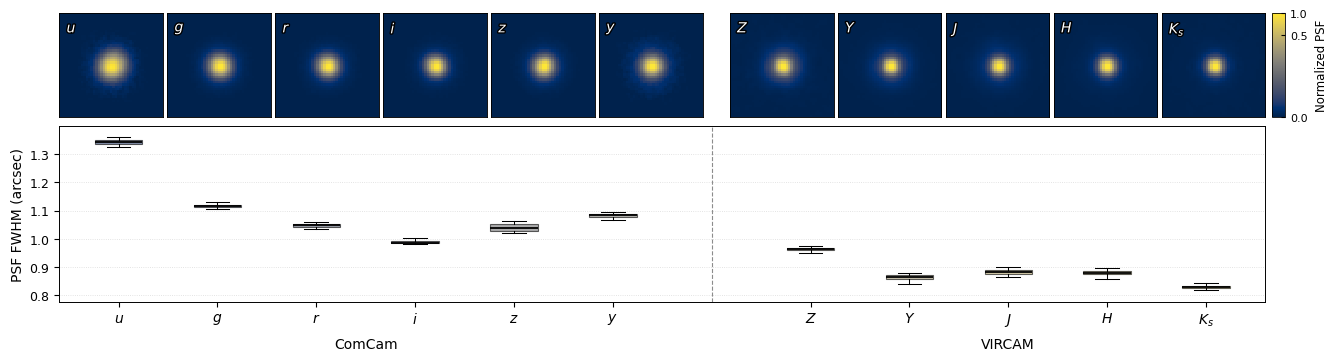

Saved diagnostic PDF: data/image_products/dp1_ecdfs_coadd_psf_boxplot_patch_16.pdf
Saved diagnostic PNG: data/image_products/dp1_ecdfs_coadd_psf_boxplot_patch_16.png


In [7]:
psf_norm = ImageNormalize(
    vmin=0.0,
    vmax=1.0,
    stretch=AsinhStretch(a=PSF_ASINH_A),
    clip=True,
)

fig = plt.figure(figsize=(13.4, 4.0))

outer_grid = fig.add_gridspec(
    nrows=2,
    ncols=1,
    height_ratios=[0.92, 1.20],
    left=0.065,
    right=0.965,
    bottom=0.18,
    top=0.98,
    hspace=0.06,
)

top_grid = outer_grid[0].subgridspec(
    nrows=1,
    ncols=12,
    width_ratios=[
        1, 1, 1, 1, 1, 1,
        0.18,
        1, 1, 1, 1, 1,
    ],
    wspace=0.045,
)

axes_top = {}

for index, band in enumerate(ALL_BANDS):
    column = band_column(index)
    ax = fig.add_subplot(top_grid[0, column])
    ax.set_box_aspect(1)
    ax.set_anchor("S")
    axes_top[band] = ax

psf_mappable = None

for band in ALL_BANDS:
    ax = axes_top[band]

    psf_mappable = ax.imshow(
        psf_display_arrays[band],
        origin="lower",
        cmap=PSF_CMAP,
        norm=psf_norm,
        interpolation="none",
    )

    ax.text(
        0.07,
        0.92,
        PANEL_LABELS[band],
        transform=ax.transAxes,
        ha="left",
        va="top",
        color="white",
        fontsize=10,
        path_effects=[
            pe.withStroke(
                linewidth=2.0,
                foreground="black",
            )
        ],
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_linewidth(0.65)
        spine.set_color("black")


ax_box = fig.add_subplot(outer_grid[1])

box_positions = np.array(
    [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12],
    dtype=float,
)

boxplot = ax_box.boxplot(
    [fwhm_samples[band] for band in ALL_BANDS],
    positions=box_positions,
    widths=0.48,
    patch_artist=True,
    showfliers=False,
    manage_ticks=False,
    boxprops={
        "linewidth": 0.8,
        "edgecolor": "black",
    },
    whiskerprops={
        "linewidth": 0.75,
        "color": "black",
    },
    capprops={
        "linewidth": 0.75,
        "color": "black",
    },
    medianprops={
        "linewidth": 1.3,
        "color": "black",
    },
)

box_cmap = plt.get_cmap(PSF_CMAP)

for index, box in enumerate(boxplot["boxes"]):
    colour_position = (
        0.18
        + 0.68 * index / (len(ALL_BANDS) - 1)
    )
    box.set_facecolor(box_cmap(colour_position))
    box.set_alpha(0.60)

ax_box.set_xticks(box_positions)
ax_box.set_xticklabels(
    [PANEL_LABELS[band] for band in ALL_BANDS],
    fontsize=10,
)

ax_box.axvline(
    7.0,
    color="0.55",
    linewidth=0.8,
    linestyle="--",
)

ax_box.set_xlim(0.4, 12.6)
ax_box.set_ylabel("PSF FWHM (arcsec)", fontsize=10)

ax_box.grid(
    axis="y",
    linestyle=":",
    linewidth=0.6,
    alpha=0.45,
)

ax_box.tick_params(axis="y", labelsize=9)

for spine in ax_box.spines.values():
    spine.set_linewidth(0.7)

all_fwhm = np.concatenate(
    [
        fwhm_samples[band]
        for band in ALL_BANDS
    ]
)

y_low, y_high = np.percentile(
    all_fwhm,
    [1.0, 99.0],
)

y_padding = max(
    0.025,
    0.08 * (y_high - y_low),
)

ax_box.set_ylim(
    max(0.0, y_low - y_padding),
    y_high + y_padding,
)

ax_box.text(
    3.5,
    -0.20,
    "ComCam",
    transform=ax_box.get_xaxis_transform(),
    ha="center",
    va="top",
    fontsize=10,
)

ax_box.text(
    10.0,
    -0.20,
    "VIRCAM",
    transform=ax_box.get_xaxis_transform(),
    ha="center",
    va="top",
    fontsize=10,
)


# Colourbar aligned with the top-row panels.
fig.canvas.draw()

top_panel_position = axes_top["K"].get_position()

cax = fig.add_axes(
    [
        top_panel_position.x1 + 0.005,
        top_panel_position.y0,
        0.010,
        top_panel_position.height,
    ]
)

cbar = fig.colorbar(
    psf_mappable,
    cax=cax,
    ticks=[0.0, 0.5, 1.0],
)

cbar.set_label(
    "Normalized PSF",
    fontsize=8.5,
    labelpad=5,
)

cbar.ax.tick_params(
    labelsize=8,
    length=3,
    direction="in",
)

cbar.outline.set_linewidth(0.6)


fig.savefig(
    BOXPLOT_PDF,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.02,
)

fig.savefig(
    BOXPLOT_PNG,
    dpi=250,
    bbox_inches="tight",
    pad_inches=0.02,
)

plt.show()

print("Saved diagnostic PDF:", BOXPLOT_PDF)
print("Saved diagnostic PNG:", BOXPLOT_PNG)

### 8. PSF stamps and spatial FWHM variation

The upper row shows the peak-normalized coadd PSF at the patch centre.
The lower row maps the local FWHM relative to the median FWHM in each
band. Red cells indicate a locally broader PSF and blue cells a locally
sharper PSF. The number in the lower-right corner gives the median
absolute FWHM in arcseconds.


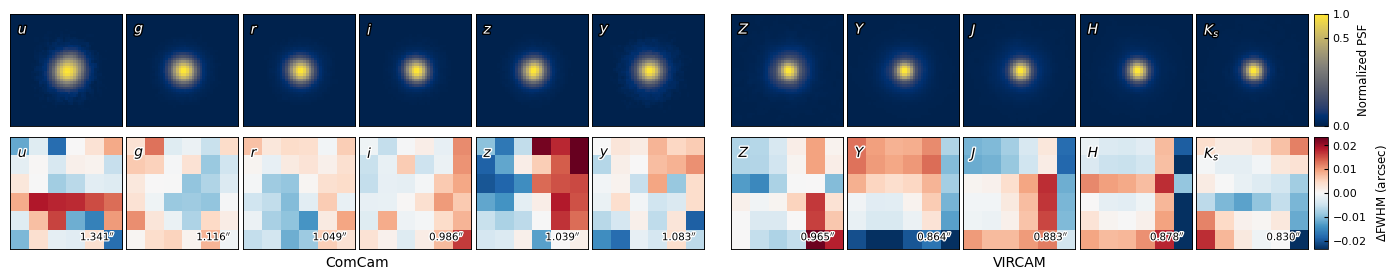

Selected patch: 16
Saved final PDF: data/image_products/dp1_ecdfs_coadd_psf_spatial_patch_16.pdf
Saved final PNG: data/image_products/dp1_ecdfs_coadd_psf_spatial_patch_16.png


In [8]:
psf_norm = ImageNormalize(
    vmin=0.0,
    vmax=1.0,
    stretch=AsinhStretch(a=PSF_ASINH_A),
    clip=True,
)

fwhm_cmap = plt.get_cmap(FWHM_MAP_CMAP).copy()
fwhm_cmap.set_bad("white")

width_ratios = (
    [1.0] * 6
    + [0.16]
    + [1.0] * 5
    + [0.12]
)

fig = plt.figure(figsize=(14.0, 3.5))

grid = fig.add_gridspec(
    nrows=3,
    ncols=13,
    width_ratios=width_ratios,
    height_ratios=[1.0, 0.08, 1.0],
    left=0.035,
    right=0.975,
    bottom=0.14,
    top=0.98,
    wspace=0.045,
    hspace=0.0,
)

axes_psf = {}
axes_map = {}

for index, band in enumerate(ALL_BANDS):
    column = band_column(index)

    axes_psf[band] = fig.add_subplot(
        grid[0, column]
    )
    axes_map[band] = fig.add_subplot(
        grid[2, column]
    )

    axes_psf[band].set_box_aspect(1)
    axes_psf[band].set_anchor("S")

    axes_map[band].set_box_aspect(1)
    axes_map[band].set_anchor("N")


# ------------------------------------------------------------------
# Upper row: normalized PSF stamps
# ------------------------------------------------------------------

psf_mappable = None

for band in ALL_BANDS:
    ax = axes_psf[band]

    ax.set_facecolor(
        plt.get_cmap(PSF_CMAP)(0.0)
    )

    psf_mappable = ax.imshow(
        psf_display_arrays[band],
        origin="lower",
        cmap=PSF_CMAP,
        norm=psf_norm,
        interpolation="none",
    )

    ax.text(
        0.07,
        0.92,
        PANEL_LABELS[band],
        transform=ax.transAxes,
        ha="left",
        va="top",
        color="white",
        fontsize=10,
        path_effects=[
            pe.withStroke(
                linewidth=2.0,
                foreground="black",
            )
        ],
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_linewidth(0.65)
        spine.set_color("black")


# ------------------------------------------------------------------
# Lower row: spatial delta-FWHM maps
# ------------------------------------------------------------------

fwhm_mappable = None

for band in ALL_BANDS:
    ax = axes_map[band]

    map_array = np.ma.masked_invalid(
        fwhm_residual_maps[band]
    )

    fwhm_mappable = ax.imshow(
        map_array,
        origin="lower",
        cmap=fwhm_cmap,
        vmin=-FWHM_RESIDUAL_LIMIT,
        vmax=FWHM_RESIDUAL_LIMIT,
        interpolation="nearest",
    )

    ax.text(
        0.07,
        0.92,
        PANEL_LABELS[band],
        transform=ax.transAxes,
        ha="left",
        va="top",
        color="black",
        fontsize=10,
        path_effects=[
            pe.withStroke(
                linewidth=2.0,
                foreground="white",
            )
        ],
    )

    ax.text(
        0.94,
        0.06,
        (
            rf"{fwhm_medians[band]:.3f}"
            rf"$^{{\prime\prime}}$"
        ),
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        color="black",
        fontsize=7.4,
        path_effects=[
            pe.withStroke(
                linewidth=1.8,
                foreground="white",
            )
        ],
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_linewidth(0.65)
        spine.set_color("black")


# ------------------------------------------------------------------
# Colourbars aligned with the corresponding panels
# ------------------------------------------------------------------

fig.canvas.draw()

top_panel_position = axes_psf["K"].get_position()
bottom_panel_position = axes_map["K"].get_position()

cax_psf = fig.add_axes(
    [
        top_panel_position.x1 + 0.004,
        top_panel_position.y0,
        0.010,
        top_panel_position.height,
    ]
)

cbar_psf = fig.colorbar(
    psf_mappable,
    cax=cax_psf,
    ticks=[0.0, 0.5, 1.0],
)

cbar_psf.set_label(
    "Normalized PSF",
    fontsize=8.5,
    labelpad=5,
)

cbar_psf.ax.tick_params(
    labelsize=8,
    length=3,
    direction="in",
)

cbar_psf.outline.set_linewidth(0.6)


cax_fwhm = fig.add_axes(
    [
        bottom_panel_position.x1 + 0.004,
        bottom_panel_position.y0,
        0.010,
        bottom_panel_position.height,
    ]
)

cbar_fwhm = fig.colorbar(
    fwhm_mappable,
    cax=cax_fwhm,
)

cbar_fwhm.set_label(
    r"$\Delta$FWHM (arcsec)",
    fontsize=8.5,
    labelpad=5,
)

cbar_fwhm.ax.tick_params(
    labelsize=8,
    length=3,
    direction="in",
)

cbar_fwhm.outline.set_linewidth(0.6)


# ------------------------------------------------------------------
# Instrument labels
# ------------------------------------------------------------------

comcam_left = axes_map["u"].get_position().x0
comcam_right = axes_map["y"].get_position().x1

vircam_left = axes_map["Z"].get_position().x0
vircam_right = axes_map["K"].get_position().x1

bottom_row_y0 = axes_map["u"].get_position().y0
group_label_y = bottom_row_y0 - 0.04

fig.text(
    0.5 * (comcam_left + comcam_right),
    group_label_y,
    "ComCam",
    ha="center",
    va="center",
    fontsize=10,
)

fig.text(
    0.5 * (vircam_left + vircam_right),
    group_label_y,
    "VIRCAM",
    ha="center",
    va="center",
    fontsize=10,
)


fig.savefig(
    FINAL_PDF,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.02,
)

fig.savefig(
    FINAL_PNG,
    dpi=250,
    bbox_inches="tight",
    pad_inches=0.02,
)

plt.show()

print("Selected patch:", SELECTED_PATCH)
print("Saved final PDF:", FINAL_PDF)
print("Saved final PNG:", FINAL_PNG)

### 9. Final paper figure

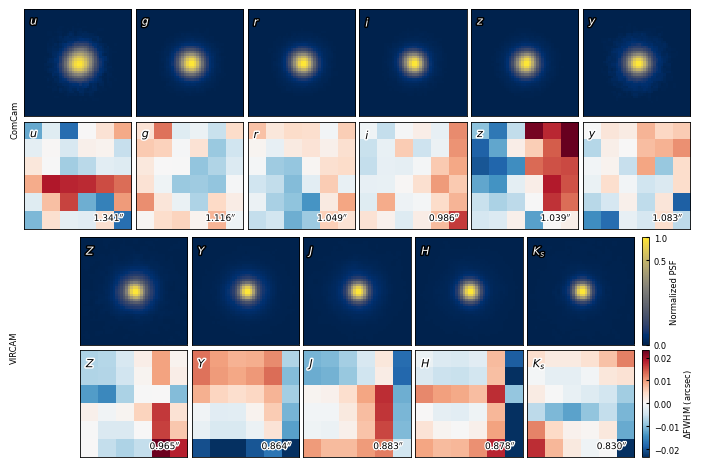

Selected patch: 16
Saved final PDF: data/image_products/dp1_ecdfs_coadd_psf_spatial_patch_16.pdf


In [9]:
# ------------------------------------------------------------------
# Display normalization
# ------------------------------------------------------------------

psf_norm = ImageNormalize(
    vmin=0.0,
    vmax=1.0,
    stretch=AsinhStretch(a=PSF_ASINH_A),
    clip=True,
)

fwhm_cmap = plt.get_cmap(
    FWHM_MAP_CMAP
).copy()

fwhm_cmap.set_bad("white")


# ------------------------------------------------------------------
# Manual geometry
#
# Same horizontal panel geometry as the UDG figure.
#
# Four rows:
#   ComCam PSF
#   ComCam FWHM
#   VIRCAM PSF
#   VIRCAM FWHM
# ------------------------------------------------------------------

fig_w = 7.4
fig_h = 5.2

fig = plt.figure(
    figsize=(fig_w, fig_h)
)


# Same horizontal geometry as the UDG figure
label_left = 0.072

panel_left = 0.085
panel_right = 0.985

panel_gap_x = 0.006

panel_w = (
    panel_right
    - panel_left
    - 5 * panel_gap_x
) / 6.0

# Square panels in physical units,
# exactly as in the UDG figure
panel_h = panel_w * (
    fig_w / fig_h
)


# ------------------------------------------------------------------
# Vertical spacing
# ------------------------------------------------------------------

# Small gap between PSF and FWHM rows
pair_gap_y = 0.010

# Gap between ComCam and VIRCAM groups
# deliberately compact
instrument_gap_y = 0.016

bottom_y = 0.055


# VIRCAM FWHM
vircam_map_y = bottom_y

# VIRCAM PSF
vircam_psf_y = (
    vircam_map_y
    + panel_h
    + pair_gap_y
)

# ComCam FWHM
comcam_map_y = (
    vircam_psf_y
    + panel_h
    + instrument_gap_y
)

# ComCam PSF
comcam_psf_y = (
    comcam_map_y
    + panel_h
    + pair_gap_y
)


# ------------------------------------------------------------------
# Horizontal placement
# ------------------------------------------------------------------

# VIRCAM rows are centred beneath ComCam,
# exactly as in the UDG figure
vircam_left = (
    panel_left
    + 0.5 * (
        panel_w
        + panel_gap_x
    )
)


axes_psf = {}
axes_map = {}


# ------------------------------------------------------------------
# ComCam rows
# ------------------------------------------------------------------

for i, band in enumerate(
    COMCAM_BANDS
):

    x0 = (
        panel_left
        + i * (
            panel_w
            + panel_gap_x
        )
    )

    axes_psf[band] = fig.add_axes(
        [
            x0,
            comcam_psf_y,
            panel_w,
            panel_h,
        ]
    )

    axes_map[band] = fig.add_axes(
        [
            x0,
            comcam_map_y,
            panel_w,
            panel_h,
        ]
    )


# ------------------------------------------------------------------
# VIRCAM rows
# ------------------------------------------------------------------

for i, band in enumerate(
    VIRCAM_BANDS
):

    x0 = (
        vircam_left
        + i * (
            panel_w
            + panel_gap_x
        )
    )

    axes_psf[band] = fig.add_axes(
        [
            x0,
            vircam_psf_y,
            panel_w,
            panel_h,
        ]
    )

    axes_map[band] = fig.add_axes(
        [
            x0,
            vircam_map_y,
            panel_w,
            panel_h,
        ]
    )


# ------------------------------------------------------------------
# PSF panels
# ------------------------------------------------------------------

psf_mappable = None

for band in ALL_BANDS:

    ax = axes_psf[band]

    ax.set_facecolor(
        plt.get_cmap(
            PSF_CMAP
        )(0.0)
    )

    psf_mappable = ax.imshow(
        psf_display_arrays[band],
        origin="lower",
        cmap=PSF_CMAP,
        norm=psf_norm,
        interpolation="none",
        rasterized=True,
    )

    ax.text(
        0.055,
        0.93,
        PANEL_LABELS[band],
        transform=ax.transAxes,
        ha="left",
        va="top",
        color="white",
        fontsize=8,
        path_effects=[
            pe.withStroke(
                linewidth=2.1,
                foreground="black",
            )
        ],
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_linewidth(0.6)
        spine.set_color("black")


# ------------------------------------------------------------------
# FWHM panels
# ------------------------------------------------------------------

fwhm_mappable = None

for band in ALL_BANDS:

    ax = axes_map[band]

    map_array = np.ma.masked_invalid(
        fwhm_residual_maps[band]
    )

    fwhm_mappable = ax.imshow(
        map_array,
        origin="lower",
        cmap=fwhm_cmap,
        vmin=-FWHM_RESIDUAL_LIMIT,
        vmax=FWHM_RESIDUAL_LIMIT,
        interpolation="nearest",
        rasterized=True,
    )

    ax.text(
        0.055,
        0.93,
        PANEL_LABELS[band],
        transform=ax.transAxes,
        ha="left",
        va="top",
        color="black",
        fontsize=8,
        path_effects=[
            pe.withStroke(
                linewidth=2.1,
                foreground="white",
            )
        ],
    )

    ax.text(
        0.94,
        0.055,
        (
            rf"{fwhm_medians[band]:.3f}"
            rf"$^{{\prime\prime}}$"
        ),
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        color="black",
        fontsize=6.5,
        path_effects=[
            pe.withStroke(
                linewidth=1.8,
                foreground="white",
            )
        ],
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_linewidth(0.6)
        spine.set_color("black")


# ------------------------------------------------------------------
# Instrument labels
#
# Same x position for both, like the UDG figure.
# Each is centred across its PSF + FWHM pair.
# ------------------------------------------------------------------

comcam_group_y = 0.5 * (
    comcam_map_y
    + comcam_psf_y
    + panel_h
)

vircam_group_y = 0.5 * (
    vircam_map_y
    + vircam_psf_y
    + panel_h
)


fig.text(
    label_left,
    comcam_group_y,
    "ComCam",
    rotation=90,
    ha="center",
    va="center",
    fontsize=6,
)

fig.text(
    label_left,
    vircam_group_y,
    "VIRCAM",
    rotation=90,
    ha="center",
    va="center",
    fontsize=6,
)


# ------------------------------------------------------------------
# Colourbars
#
# Both on the right side:
#   - PSF colourbar beside the VIRCAM PSF row
#   - FWHM colourbar beside the VIRCAM FWHM row
# ------------------------------------------------------------------

fig.canvas.draw()

z_psf_pos = axes_psf["Z"].get_position()
ks_psf_pos = axes_psf["K"].get_position()
ks_map_pos = axes_map["K"].get_position()

cbar_w = 0.010

# ------------------------------------------------------------
# PSF colourbar:
# same height as one PSF panel,
# placed to the right of the VIRCAM PSF row
# ------------------------------------------------------------

cax_psf = fig.add_axes(
    [
        ks_psf_pos.x1 + 0.010,
        z_psf_pos.y0,
        cbar_w,
        z_psf_pos.height,
    ]
)

cbar_psf = fig.colorbar(
    psf_mappable,
    cax=cax_psf,
    ticks=[0.0, 0.5, 1.0],
)

cbar_psf.set_label(
    "Normalized PSF",
    fontsize=6,
    labelpad=2,
)

cbar_psf.ax.tick_params(
    labelsize=6,
    length=2,
    direction="in",
)

cbar_psf.outline.set_linewidth(0.6)


# ------------------------------------------------------------
# FWHM colourbar:
# same height as one FWHM panel,
# placed to the right of the Ks FWHM panel
# ------------------------------------------------------------

cax_fwhm = fig.add_axes(
    [
        ks_map_pos.x1 + 0.010,
        ks_map_pos.y0,
        cbar_w,
        ks_map_pos.height,
    ]
)

cbar_fwhm = fig.colorbar(
    fwhm_mappable,
    cax=cax_fwhm,
)

cbar_fwhm.set_label(
    r"$\Delta$FWHM (arcsec)",
    fontsize=6,
    labelpad=2,
)

cbar_fwhm.ax.tick_params(
    labelsize=6,
    length=2,
    direction="in",
)

cbar_fwhm.outline.set_linewidth(0.6)


# ------------------------------------------------------------------
# Save
# ------------------------------------------------------------------

fig.savefig(
    FINAL_PDF,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.02,
)

fig.savefig(
    FINAL_PNG,
    dpi=250,
    bbox_inches="tight",
    pad_inches=0.02,
)

plt.show()

print(
    "Selected patch:",
    SELECTED_PATCH,
)

print(
    "Saved final PDF:",
    FINAL_PDF,
)